# MSFT Stock Market Price Forecast

This proyect aims to forecast 1 day ahead $MSFT utilising **Prophet Model**.

### Libraries

In [1]:
# yahoo finance
import yfinance as yf
# Data manipulation
import pandas as pd
import numpy as np
##Plots
import matplotlib.pyplot as plt
import seaborn as sns

#Prophet model
from prophet import Prophet

# Accuracy
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from math import sqrt

#random seachcv
from sklearn.model_selection import RandomizedSearchCV
import random

### Loading Data

In [2]:
# Data ingestion
data = yf.download('MSFT', start='2000-01-01', end='2026-03-04')
data= data.asfreq('B') #bussines day frequency
data = data.ffill() #interpolate missing values

[*********************100%***********************]  1 of 1 completed


In [163]:
d = yf.download("MSFT", start="2000-01-01", end="2026-03-03")
d.reset_index(inplace=True)
d

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,MSFT,MSFT,MSFT,MSFT,MSFT
0,2000-01-03,35.520382,36.148893,34.130040,35.767977,53228400
1,2000-01-04,34.320488,35.691784,34.206213,34.606175,54119000
2,2000-01-05,34.682365,35.463242,33.330115,33.863397,64059600
3,2000-01-06,33.520573,34.701411,33.025382,34.187175,54976600
4,2000-01-07,33.958614,34.206209,32.701593,33.101555,62013600
...,...,...,...,...,...,...
6574,2026-02-24,389.000000,389.359985,381.709991,384.140015,33884700
6575,2026-02-25,400.600006,401.470001,390.160004,390.529999,43625500
6576,2026-02-26,401.720001,407.489990,398.739990,404.709991,34405900


In [124]:
data

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2000-01-03,35.520370,36.148881,34.130029,35.767966,53228400.0
2000-01-04,34.320499,35.691796,34.206225,34.606186,54119000.0
2000-01-05,34.682343,35.463219,33.330093,33.863375,64059600.0
2000-01-06,33.520569,34.701407,33.025379,34.187171,54976600.0
2000-01-07,33.958614,34.206209,32.701593,33.101555,62013600.0
...,...,...,...,...,...
2026-02-25,400.600006,401.470001,390.160004,390.529999,43625500.0
2026-02-26,401.720001,407.489990,398.739990,404.709991,34405900.0


### Data Preprocessing

In [3]:
# Check if it's MultiIndex
if isinstance(data.columns, pd.MultiIndex):
    # Flatten the MultiIndex
    data.columns = data.columns.map(lambda x: x[0])  # Keep only the first level of the MultiIndex

In [4]:
df=data.reset_index()

In [127]:
df

,Date,Close,High,Low,Open,Volume
0,2000-01-03,35.520370,36.148881,34.130029,35.767966,53228400.0
1,2000-01-04,34.320499,35.691796,34.206225,34.606186,54119000.0
2,2000-01-05,34.682343,35.463219,33.330093,33.863375,64059600.0
3,2000-01-06,33.520569,34.701407,33.025379,34.187171,54976600.0
4,2000-01-07,33.958614,34.206209,32.701593,33.101555,62013600.0
...,...,...,...,...,...,...
6822,2026-02-25,400.600006,401.470001,390.160004,390.529999,43625500.0
6823,2026-02-26,401.720001,407.489990,398.739990,404.709991,34405900.0
6824,2026-02-27,392.739990,396.820007,389.880005,390.880005,51367200.0
6825,2026-03-02,398.549988,401.190002,390.630005,392.859985,35474900.0


In [5]:
df = df.rename(columns={'Date': 'ds', 'Close': 'y'})

In [130]:
df.head()

,ds,y,High,Low,Open,Volume
0,2000-01-03,35.520370,36.148881,34.130029,35.767966,53228400.0
1,2000-01-04,34.320499,35.691796,34.206225,34.606186,54119000.0
2,2000-01-05,34.682343,35.463219,33.330093,33.863375,64059600.0
3,2000-01-06,33.520569,34.701407,33.025379,34.187171,54976600.0
4,2000-01-07,33.958614,34.206209,32.701593,33.101555,62013600.0


In [56]:
#df.set_index('ds', inplace=True)
df.shape

(6826, 5)

#### Test and Train dataset

In [6]:
train, test = df[:-60], df[-60:]

### Exogenous variables

In [7]:
X=['High','Low','Open','Volume']

### Prophet Model

In [133]:
# Initialize Prophet model
model = Prophet(growth='linear',
    yearly_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=0.1,       # allow more trend flexibility
    seasonality_prior_scale=20.0, ) 

In [134]:
# add regressors (exogenous variables)

for x in X:
    model.add_regressor(x, standardize='auto')

In [135]:
# checking for exogenous variables that the model expects
print("Model expects:", list(model.extra_regressors.keys()))

Model expects: ['High', 'Low', 'Open', 'Volume']


In [136]:
# Fit the model using train data
model.fit(train)

23:26:19 - cmdstanpy - INFO - Chain [1] start processing
23:26:24 - cmdstanpy - INFO - Chain [1] done processing


### Predict

In [137]:
predicted=model.predict(test)

### Accuracy

In [138]:
# Compute accuracy metrics
rmse = np.sqrt(mean_squared_error(test['y'], predicted['yhat']))
mae = mean_absolute_error(test['y'], predicted['yhat'])
r2 = r2_score(test['y'], predicted['yhat'])
mape = mean_absolute_percentage_error(test['y'], predicted['yhat'])

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:4f}")

RMSE: 1.9797
MAE: 1.4517
R² Score: 0.9970
MAPE: 0.003318


In [140]:
test.tail()

,ds,y,High,Low,Open,Volume
6822,2026-02-25,400.600006,401.470001,390.160004,390.529999,43625500.0
6823,2026-02-26,401.720001,407.489990,398.739990,404.709991,34405900.0
6824,2026-02-27,392.739990,396.820007,389.880005,390.880005,51367200.0
6825,2026-03-02,398.549988,401.190002,390.630005,392.859985,35474900.0
6826,2026-03-03,403.929993,406.700012,392.679993,393.140015,37947881.0


### Actual VS Predicted Plot

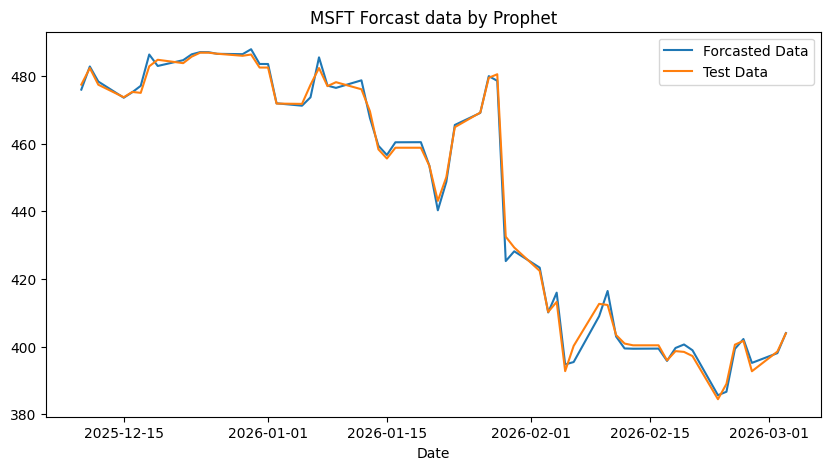

In [139]:
# Plot test data vs forecasted data
plt.figure(figsize=(10, 5))
plt.plot(test['ds'], predicted['yhat'], label='Forcasted Data')
plt.plot(test['ds'], test['y'], label='Test Data')
plt.title('MSFT Forcast data by Prophet')
plt.xlabel('Date')
plt.legend()
plt.show()

### Forecasting 1 Day Ahead

In [141]:
# Create a DataFrame for the specific future date (04/03/2026)
future = pd.DataFrame({
    'ds': pd.to_datetime(['2026-03-04']),  
    'High': [df['High'].iloc[-1]], 
    'Low': [df['Low'].iloc[-1]],    
    'Open': [df['Open'].iloc[-1]],  
    'Volume': [df['Volume'].iloc[-1]] 
    })


In [143]:
# Generate forecasts
forecast = model.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,High,High_lower,High_upper,Low,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2026-03-04,87.775995,402.839356,405.113259,87.775995,87.775995,245.95252,245.95252,245.95252,250.67928,...,10.408318,10.408318,10.408318,0.027257,0.027257,0.027257,0.0,0.0,0.0,403.988162


### Forecast Plot

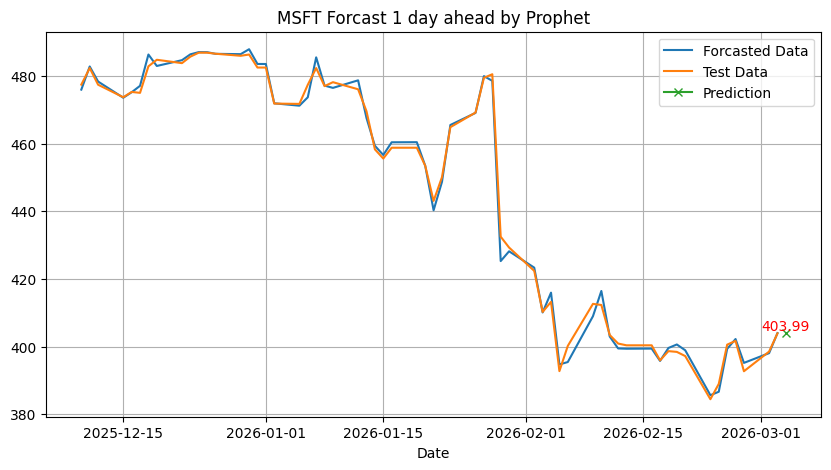

In [162]:
# Plot test data vs forecasted data
plt.figure(figsize=(10, 5))
plt.plot(test['ds'], predicted['yhat'], label='Forcasted Data')
plt.plot(test['ds'], test['y'], label='Test Data')
plt.plot(forecast['ds'], forecast['yhat'], label='Prediction', marker='x',)
#plt.axvline(pd.Timestamp('2026-03-04'), color='r', linestyle='--') 
for index, row in forecast.iterrows():
    plt.text(row['ds'], row['yhat'], f"{row['yhat']:.2f}", color='red', fontsize=10, ha='center', va='bottom')
plt.title('MSFT Forcast 1 day ahead by Prophet')
plt.xlabel('Date')
plt.grid()
plt.legend()
plt.show()

### Best Parameters

In [25]:
#function for random choice of parameters
def param_choice():
    return {
        'growth': 'linear',
        'seasonality_mode': random.choice(['additive', 'multiplicative']),
        'yearly_seasonality': random.choice([7, 10, 13, 16, 20]),
        'weekly_seasonality': random.choice([0, 3, 5, 7, 10]),
        'daily_seasonality': random.choice([0]),
        'changepoint_prior_scale': random.choice([0.001, 0.003, 0.01, 0.03, 0.1]),
        'changepoint_range': random.choice([0.80, 0.85, 0.90, 0.95]),
        'n_changepoints': random.choice([10, 15, 20, 24, 30, 40]),
        'seasonality_prior_scale': random.choice([0.5, 1, 2, 5, 10]),
        'holidays_prior_scale': random.choice([0.1, 0.3, 1, 3, 10]),
        'regressor_mode': random.choice(['additive', 'multiplicative']),
        'regressor_prior_scale': random.choice([0.1, 0.3, 1, 3, 10]),
    }

In [26]:
#define model and score function
def fit_and_score(params):
    model_rs = Prophet(
        growth='linear',
        seasonality_mode=params['seasonality_mode'],
        yearly_seasonality=params['yearly_seasonality'],
        weekly_seasonality=params['weekly_seasonality'],
        daily_seasonality=params['daily_seasonality'],
        changepoint_prior_scale=params['changepoint_prior_scale'],
        changepoint_range=params['changepoint_range'],
        n_changepoints=params['n_changepoints'],
        seasonality_prior_scale=params['seasonality_prior_scale'],
        holidays_prior_scale=params['holidays_prior_scale'],
    )
   

# model train
    model_rs.fit(train)

# model predictions   
    predicted_rs = model_rs.predict(test)

# y_true index and values
    y_true = test.set_index('ds').loc[test['ds'], 'y'].values

# score is mae
    score = mean_absolute_error(y_true, predicted_rs['yhat'].values)
    
    return score, model_rs, predicted_rs[['ds','yhat','yhat_lower','yhat_upper']]


#### Random Search

In [27]:
# Random search 
trails = 100 #epochs
best_score = np.inf
best = None

for i in range(1, trails+1):
    p = param_choice()
    try:
        score, model_rs, predicted_rs = fit_and_score(p)
        if score < best_score:
            best_score = score
            best = {'params': p, 'model': model_rs, 'forecast_test': predicted_rs, 'mae': score}
        print(f"Trial {i:02d}: MAE={score:.3f}  params={p}")
    except Exception as e:
        print(f"Trial {i:02d} failed: {e}")

print("\nBest MAE:", round(best['mae'], 3))
print("Best Params:", best['params'])

22:31:18 - cmdstanpy - INFO - Chain [1] start processing
22:31:27 - cmdstanpy - INFO - Chain [1] done processing


Trial 01: MAE=48.409  params={'growth': 'linear', 'seasonality_mode': 'multiplicative', 'yearly_seasonality': 10, 'weekly_seasonality': 5, 'daily_seasonality': 0, 'changepoint_prior_scale': 0.1, 'changepoint_range': 0.95, 'n_changepoints': 40, 'seasonality_prior_scale': 0.5, 'holidays_prior_scale': 3, 'regressor_mode': 'multiplicative', 'regressor_prior_scale': 10}


22:31:28 - cmdstanpy - INFO - Chain [1] start processing
22:31:34 - cmdstanpy - INFO - Chain [1] done processing


Trial 02: MAE=69.524  params={'growth': 'linear', 'seasonality_mode': 'multiplicative', 'yearly_seasonality': 16, 'weekly_seasonality': 10, 'daily_seasonality': 0, 'changepoint_prior_scale': 0.003, 'changepoint_range': 0.9, 'n_changepoints': 24, 'seasonality_prior_scale': 0.5, 'holidays_prior_scale': 10, 'regressor_mode': 'additive', 'regressor_prior_scale': 0.3}


22:31:35 - cmdstanpy - INFO - Chain [1] start processing
22:31:36 - cmdstanpy - INFO - Chain [1] done processing


...

Trial 98: MAE=39.170  params={'growth': 'linear', 'seasonality_mode': 'multiplicative', 'yearly_seasonality': 13, 'weekly_seasonality': 7, 'daily_seasonality': 0, 'changepoint_prior_scale': 0.03, 'changepoint_range': 0.85, 'n_changepoints': 20, 'seasonality_prior_scale': 5, 'holidays_prior_scale': 3, 'regressor_mode': 'additive', 'regressor_prior_scale': 0.1}


22:39:07 - cmdstanpy - INFO - Chain [1] start processing
22:39:08 - cmdstanpy - INFO - Chain [1] done processing


Trial 99: MAE=35.198  params={'growth': 'linear', 'seasonality_mode': 'additive', 'yearly_seasonality': 13, 'weekly_seasonality': 0, 'daily_seasonality': 0, 'changepoint_prior_scale': 0.001, 'changepoint_range': 0.95, 'n_changepoints': 24, 'seasonality_prior_scale': 10, 'holidays_prior_scale': 1, 'regressor_mode': 'additive', 'regressor_prior_scale': 10}


22:39:08 - cmdstanpy - INFO - Chain [1] start processing
22:39:10 - cmdstanpy - INFO - Chain [1] done processing


Trial 100: MAE=33.786  params={'growth': 'linear', 'seasonality_mode': 'multiplicative', 'yearly_seasonality': 10, 'weekly_seasonality': 0, 'daily_seasonality': 0, 'changepoint_prior_scale': 0.03, 'changepoint_range': 0.8, 'n_changepoints': 40, 'seasonality_prior_scale': 2, 'holidays_prior_scale': 10, 'regressor_mode': 'multiplicative', 'regressor_prior_scale': 1}

Best MAE: 33.12
Best Params: {'growth': 'linear', 'seasonality_mode': 'multiplicative', 'yearly_seasonality': 16, 'weekly_seasonality': 0, 'daily_seasonality': 0, 'changepoint_prior_scale': 0.001, 'changepoint_range': 0.95, 'n_changepoints': 30, 'seasonality_prior_scale': 1, 'holidays_prior_scale': 0.3, 'regressor_mode': 'multiplicative', 'regressor_prior_scale': 1}


In [28]:
#Best parameters
print("Best Params:", best['params'])

Best Params: {'growth': 'linear', 'seasonality_mode': 'multiplicative', 'yearly_seasonality': 16, 'weekly_seasonality': 0, 'daily_seasonality': 0, 'changepoint_prior_scale': 0.001, 'changepoint_range': 0.95, 'n_changepoints': 30, 'seasonality_prior_scale': 1, 'holidays_prior_scale': 0.3, 'regressor_mode': 'multiplicative', 'regressor_prior_scale': 1}


### Prophet Model with Best Parameters

In [8]:
# Best parameters Model
model_best= Prophet(
    growth= 'linear',
    seasonality_mode= 'multiplicative',
    yearly_seasonality= 16,
    weekly_seasonality= 0,
    daily_seasonality= 0, 
    changepoint_prior_scale= 0.001,
    changepoint_range= 0.95,
    n_changepoints= 30,
    seasonality_prior_scale= 1,
    holidays_prior_scale= 0.3,

                )

In [10]:
# add regressors (exogenous variables)

for x in X:
    model_best.add_regressor(x, standardize='auto')

In [11]:
model_best.fit(train)

22:40:07 - cmdstanpy - INFO - Chain [1] start processing
22:40:15 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
predicted_best=model_best.predict(test)

### Accuracy (Best Parameters)

In [13]:
# Compute accuracy metrics
rmse = np.sqrt(mean_squared_error(test['y'], predicted_best['yhat']))
mae = mean_absolute_error(test['y'], predicted_best['yhat'])
r2 = r2_score(test['y'], predicted_best['yhat'])
mape=mean_absolute_percentage_error(test['y'], predicted_best['yhat'])

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f'MAPE: {mape:.4f}')

RMSE: 1.9597
MAE: 1.4420
R² Score: 0.9971
MAPE: 0.0033


### Actual vs Predicted (Best Parameters)

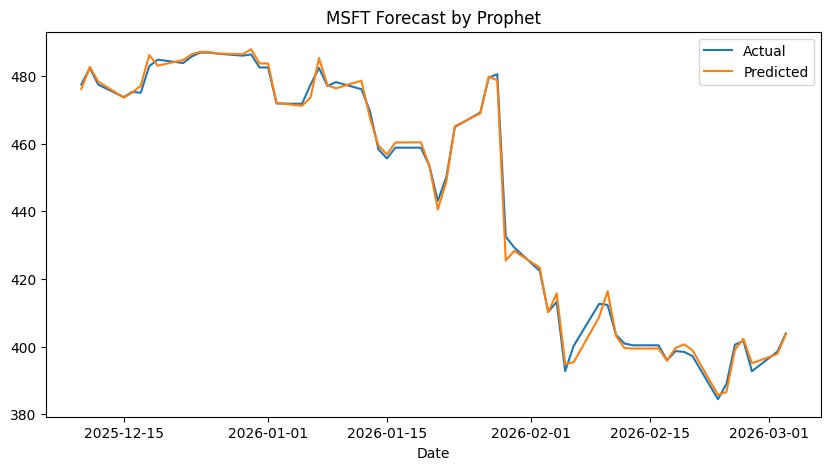

In [14]:
# Plot test data vs forecasted data
plt.figure(figsize=(10, 5))
plt.plot(test['ds'], test['y'], label='Actual')
plt.plot(test['ds'], predicted_best['yhat'], label='Predicted')
plt.title('MSFT Forecast by Prophet')
plt.xlabel('Date')
plt.legend()
plt.show()

### Forecasting 1 Day Ahead (Best Parameters)

In [16]:
# Create a DataFrame for the specific future date (04/03/2026)
future = pd.DataFrame({
    'ds': pd.to_datetime(['2026-03-04']),  
    'High': [df['High'].iloc[-1]], 
    'Low': [df['Low'].iloc[-1]],    
    'Open': [df['Open'].iloc[-1]],  
    'Volume': [df['Volume'].iloc[-1]] 
    })


In [17]:
# Generate forecasts
forecast = model_best.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,High,High_lower,High_upper,Low,...,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,2026-03-04,98.180958,402.535943,404.837026,98.180958,98.180958,2.421385,2.421385,2.421385,2.537696,...,3.111343,3.111343,3.111343,-0.00003,-0.00003,-0.00003,0.0,0.0,0.0,403.655577


### Forecast Plot (Best Prameters)

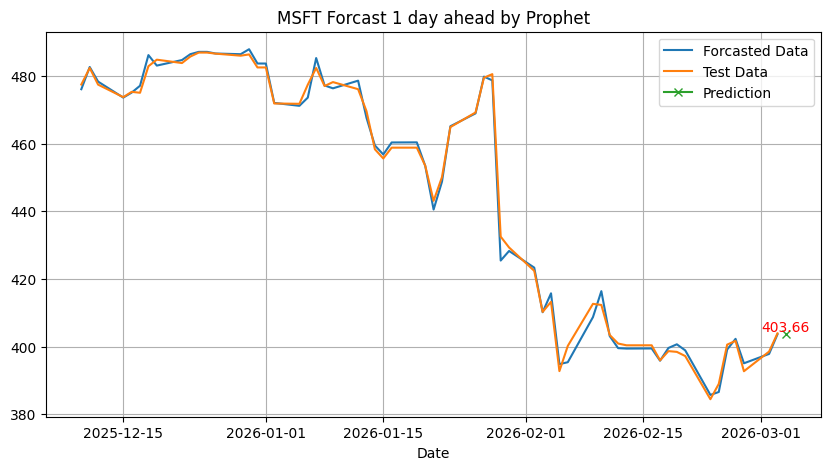

In [19]:
# Plot test data vs forecasted data
plt.figure(figsize=(10, 5))
plt.plot(test['ds'], predicted_best['yhat'], label='Forcasted Data')
plt.plot(test['ds'], test['y'], label='Test Data')
plt.plot(forecast['ds'], forecast['yhat'], label='Prediction', marker='x',)
#plt.axvline(pd.Timestamp('2026-03-04'), color='r', linestyle='--') 
for index, row in forecast.iterrows():
    plt.text(row['ds'], row['yhat'], f"{row['yhat']:.2f}", color='red', fontsize=10, ha='center', va='bottom')
plt.title('MSFT Forcast 1 day ahead by Prophet')
plt.xlabel('Date')
plt.grid()
plt.legend()
plt.show()